### Segment the heart
In this chapter, we'll work with magnetic resonance (MR) imaging data from the Sunnybrook Cardiac Dataset. The full image is a 3D time series spanning a single heartbeat. These data are used by radiologists to measure the ejection fraction: the proportion of blood ejected from the left ventricle during each stroke.

To begin, segment the left ventricle from a single slice of the volume (im). First, you'll filter and mask the image; then you'll label each object with ndi.label().

This chapter's exercises have the following imports:

import imageio
import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

In [ ]:
import imageio
import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

- Apply a median filter to im. Set the size to 3.
- Create a mask of values greater than 60, then use ndi.binary_closing() to fill small holes in it.
- Extract a labeled array and the number of labels using ndi.label().

In [ ]:
# Smooth intensity values
im_filt = ndi.median_filter(im, size=3)

# Select high-intensity pixels
mask_start = np.where(im_filt > 60, 1, 0)
mask = ndi.binary_closing(mask_start)

# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)

Num. Labels: 26

Plot the labels array on top of the original image. To create an overlay, use np.where to convert values of 0 to np.nan. Then, plot the overlay with the rainbow colormap and set alpha=0.75 to make it transparent.



In [ ]:
# Create a `labels` overlay
overlay = np.where(labels > 0, labels, np.nan)

# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
format_and_render_plot()

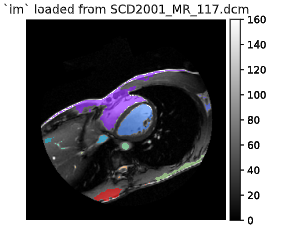

Robust image segmentation is an entire research domain, but the simple principle is to leverage intensity and location information to differentiate objects of interest from the background. Once labeled, the objects can be manipulated easily.

- Use ndi.label() to assign labels to each separate object in mask.
- Find the index value for the left ventricle label by checking the center pixel (128, 128).
- Create a mask of pixels matching the left ventricle label. Using np.where, set pixels labeled as lv_val to 1 and other values to np.nan.
- Use plt.imshow() to overlay the selected label on the current plot.

In [ ]:
# Label the image "mask"
labels, nlabels = ndi.label(mask)

# Select left ventricle pixels
lv_val = labels[128, 128]
lv_mask = np.where(labels == lv_val, 1, np.nan)

# Overlay selected label
plt.imshow(lv_mask, cmap='rainbow')
plt.show()

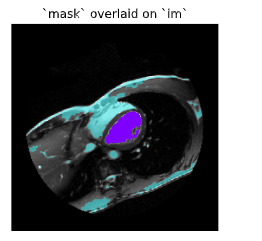

## Extract objects
Extracting objects from the original image eliminates unrelated pixels and provides new images that can be analyzed independently.

The key is to crop images so that they only include the object of interest. The range of pixel indices that encompass the object is the bounding box.

For this exercise, use ndi.find_objects() to create a new image containing only the left ventricle.

Create the labels array from mask, then create a mask left ventricle pixels. (Use the coordinates 128, 128 to find the left ventricle label value.)

In [ ]:
# Create left ventricle mask
labels, nlabels = ndi.label(mask)
lv_val = labels[128,128]
lv_mask = np.where(labels == lv_val, 1, 0)

Find the bounding box indices for lv_mask. Print the number of objects found and the values for the first box.

In [ ]:
# Create left ventricle mask
labels, nlabels = ndi.label(mask)
lv_val = labels[128, 128]
lv_mask = np.where(labels == lv_val, 1, 0)

# Find bounding box of left ventricle
bboxes =ndi.find_objects(lv_mask)
print('Number of objects:', len(bboxes))
print('Indices for first box:', bboxes[0])

Number of objects: 1
Indices for first box: (slice(107, 149, None), slice(116, 162, None))

- Select the portion of im that is within the left ventricle bounding box.
- Plot the cropped image.

In [ ]:
# Create left ventricle mask
labels, nlabels = ndi.label(mask)
lv_val = labels[128, 128]
lv_mask = np.where(labels == lv_val, 1, 0)

# Find bounding box of left ventricle
bboxes = ndi.find_objects(lv_mask)
print('Number of objects:', len(bboxes))
print('Indices for first box:', bboxes[0])

# Crop to the left ventricle (index 0)
im_lv = im[bboxes[0]]

# Plot the cropped image
plt.imshow(im_lv)
format_and_render_plot()

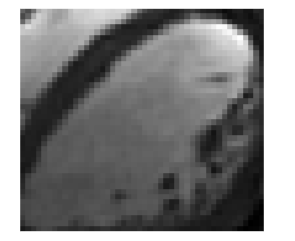